In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# 1. Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()



In [23]:
print("Training data shape:", x_train.shape, y_train.shape)

Training data shape: (60000, 28, 28) (60000, 10)


In [6]:
# 2. Normalize & preprocess
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)



In [ ]:
# 3. Build ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)),  # input layer
    Dense(128, activation='relu'),  # hidden layer
    Dense(10, activation='softmax') # output layer 
])

# 4. Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train model
model.fit(x_train, y_train, epochs=5, batch_size=32, verbose=2)

# 6. Evaluate model
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")


2025-08-08 18:33:57.344829: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5
1875/1875 - 7s - 4ms/step - accuracy: 0.9246 - loss: 0.2635
Epoch 2/5
1875/1875 - 6s - 3ms/step - accuracy: 0.9658 - loss: 0.1151
Epoch 3/5
1875/1875 - 6s - 3ms/step - accuracy: 0.9759 - loss: 0.0788
Epoch 4/5
1875/1875 - 6s - 3ms/step - accuracy: 0.9819 - loss: 0.0591
Epoch 5/5
1875/1875 - 6s - 3ms/step - accuracy: 0.9855 - loss: 0.0466
Test Accuracy: 97.80%


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


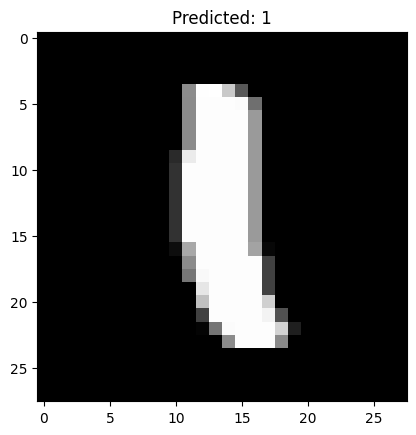

In [27]:
import matplotlib.pyplot as plt
import numpy as np

predictions = model.predict(x_test)
idx = np.random.randint(0, len(x_test))
plt.imshow(x_test[idx], cmap='gray')
plt.title(f"Predicted: {predictions[idx].argmax()}")
plt.show()
